In [ ]:
import torch
import physics_modelling.N_layer_system as pms
import physics_modelling.subsystems as ss
import training_testing.target_class as tc
import training_testing.train_validate as tv
import training_testing.digits_generator as dg
import training_testing.npcc as cc
import imperfection_testing.extract_modulation as em
import imperfection_testing.misalignment_classes as mc
import csv
import dataclasses as dc
import matplotlib.pyplot as plt

In [45]:
import importlib

importlib.reload(mc)




<module 'imperfection_testing.misalignment_classes' from 'c:\\Users\\georg\\OneDrive\\Documents\\4th_year\\optical computing\\d2nn_misalign\\imperfection_testing\\misalignment_classes.py'>

Optical configuration

In [ ]:
config = ss.OpticalConfig(
    532e-9,
    5e-6,
    256,
    256,
    4e-3
)

distance = 0.2 

# assume all distances the same
def distances(n):
    return distance*torch.ones(n+1).unsqueeze(0)


Testing parameters

In [132]:
train_size = 4096
val_size = 4096
batch_size = 64
train_loader, val_loader = dg.data_set_generation(config.height, config.width, train_size, val_size, batch_size)
criterion = cc.npcc_loss
target_pos = 50
half_target_size = 10
target_method = tc.targets(config.height, config.width, target_pos, target_pos, half_target_size)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = cc.npcc_loss




Trained systems

In [ ]:
files = ['training_testing/training_system/d2nn1/nn50.pt',
         'training_testing/training_system/d2nn2/nn35.pt',
         'training_testing/training_system/d2nn3/round2/nn3.pt',
         'training_testing/training_system/d2nn4/nn22.pt',
         'training_testing/training_system/d2nn5/nn44.pt'
         ]


General function for initilaising and validating

In [131]:
def create_val(config, modulation):
    n = len(modulation)
    d2nn = pms.IdealSystem(config,distances(n),False,modulation)
    _, acc, _,_ = tv.validation(d2nn, val_loader, criterion, target_method, device)
    return acc

Initialising, validating after quantizing to n bits

In [136]:
def quant_val(config, modulation,  n):
    modulation = em.quantise_nbit(modulation, n)
    return create_val(config, modulation)
    

Initialising and validating with a new beam waist

In [137]:
def waist_val(config, modulation, waist):
    # making a copy of the config but with the new waist. replace a missleading method name
    config_temp = dc.replace(config, beam_waist = waist)
    return create_val(config_temp, modulation)


Writing to csv function

In [26]:
def save_csv(file, header, rows):
    with open(file, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(header)     
        writer.writerows(rows)     

Running loops on both quantization and beam waist

In [138]:
header = [ 'no_layers' ]

bits = [ 2, 3 ,4, 5, 6, 7, 8, 9, 10 ]
waists = [ 1e-4, 2e-4, 3e-4, 4e-4, 5e-4, 6e-4, 7e-4, 8e-4, 9e-4, 1e-3 ]

header_q = header + bits
header_w = header + waists

rows_q = []
rows_w = []

for i, file in enumerate( files ):

    mod_tmp = em.extract_params( file )
    row_q = [i+1]
    row_w = [i+1]

    for _,bit in enumerate( bits ):
        acc = quant_val(config, mod_tmp, bit)
        row_q.append( acc )
    
    for _,waist in enumerate( waists):
        acc = waist_val( config, mod_tmp, waist)
        row_w.append(acc)

    rows_q.append(row_q)
    rows_w.append(row_w)


save_csv( 'quantization.csv', header_q, rows_q )
save_csv( 'waist_size.csv', header_w, rows_w )



Plotting quantization

In [116]:

def plot_acc(header,rows, 
             end_index, 
             x_label, 
             x_lims = None, 
             y_lims = None, 
             x_ticks = None, 
             y_ticks = None, 
             difference=False
             ):
    
    colors = [
    "#6FA8DC",  # stronger blue
    "#E06666",  # muted red
    "#93C47D",  # green
    "#F6B26B",  # orange
    "#B4A7D6"   # purple
    ]

    rows_tmp = 100*torch.tensor(rows)
    if difference is True:
        rows_tmp = rows_tmp - rows_tmp[:,-1].unsqueeze(1)
        print
    for i,item in enumerate(colors):
        plt.plot(header[1:end_index], 
                 rows_tmp[i,1:end_index], 
                 linewidth=1, 
                 label=f'{i+1} Layers', 
                 color = item, marker='o'
                 )

    plt.xlabel(x_label)

    if difference == True:
        plt.ylabel('Difference in Accuracy from ideal (%)')
    else:
        plt.ylabel('Raw Accuracy (%)')

    if x_lims != None: 
        plt.xlim(x_lims)
    if y_lims != None:
        plt.ylim(y_lims)
    if x_ticks != None:
        plt.xticks(x_ticks)
    if y_ticks != None:
        plt.yticks(y_ticks)

    plt.legend()
    plt.show()



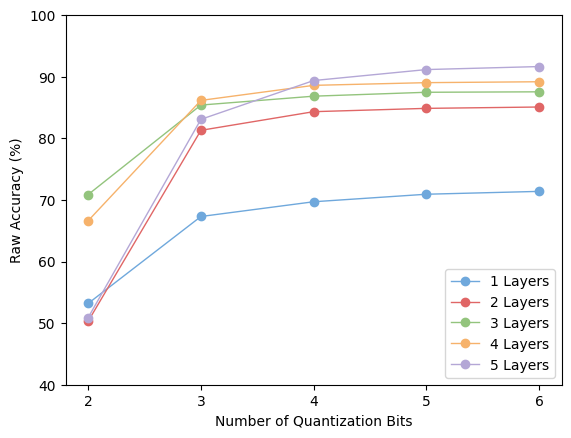

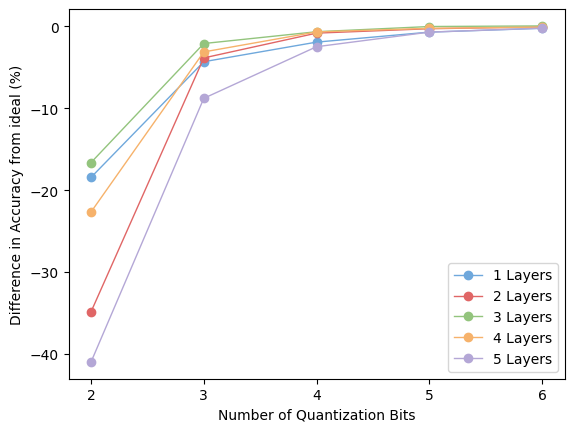

In [143]:
plot_acc(header_q, rows_q, 6 , 'Number of Quantization Bits', x_ticks=[2,3,4,5,6], y_lims=(40,100))
plot_acc(header_q, rows_q, 6 , 'Number of Quantization Bits', x_ticks=[2,3,4,5,6], difference=True)

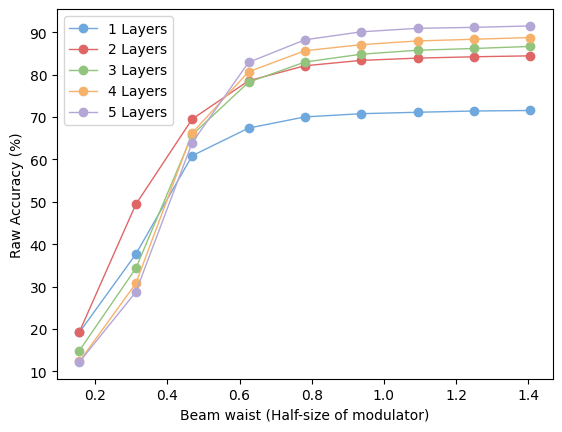

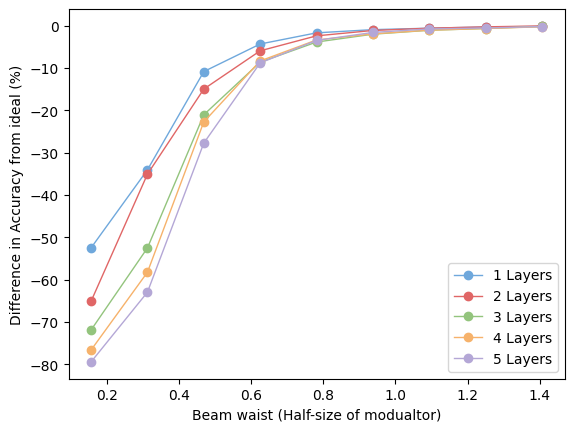

In [148]:
half_width = config.pixel_size * config.height / 2
header_w2 = [0] + waists
header_w2 = torch.tensor(header_w2)/half_width
plot_acc(header_w2, rows_w, 10 , 'Beam waist (Half-size of modulator)', )
plot_acc(header_w2, rows_w, 10 , 'Beam waist (Half-size of modualtor)', difference=True)
